In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt

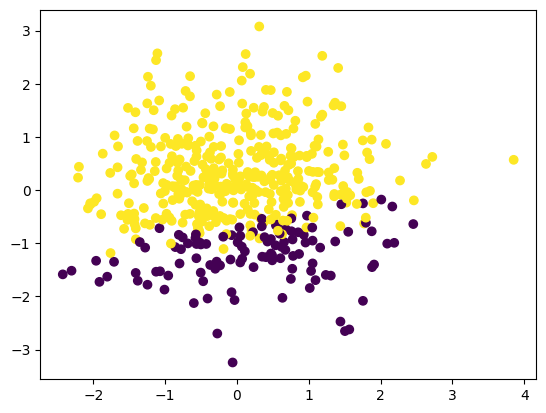

In [3]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

In [90]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (8000, 6), y size : (8000,)


50. Training loss: 0.33734921986813615, Val loss:0.34928948182311964
100. Training loss: 0.27930058746073855, Val loss:0.29644225845982586
150. Training loss: 0.25187101386973687, Val loss:0.2708356317729795
200. Training loss: 0.23493074654215668, Val loss:0.2547004113219481
250. Training loss: 0.22309044085112176, Val loss:0.2432533086604643
300. Training loss: 0.21423026791605443, Val loss:0.23459345721849548
350. Training loss: 0.20730456831126828, Val loss:0.2277697205498992
400. Training loss: 0.20172171749954612, Val loss:0.22223588752930548
450. Training loss: 0.19711585512236277, Val loss:0.21764953662604497
500. Training loss: 0.1932462389757469, Val loss:0.21378268647513837
550. Training loss: 0.18994696674507142, Val loss:0.21047664529879215
600. Training loss: 0.18709950282057058, Val loss:0.2076170870758348
650. Training loss: 0.1846166422902798, Val loss:0.20511930742690124
700. Training loss: 0.18243265336778453, Val loss:0.2029190893484123
750. Training loss: 0.1804969

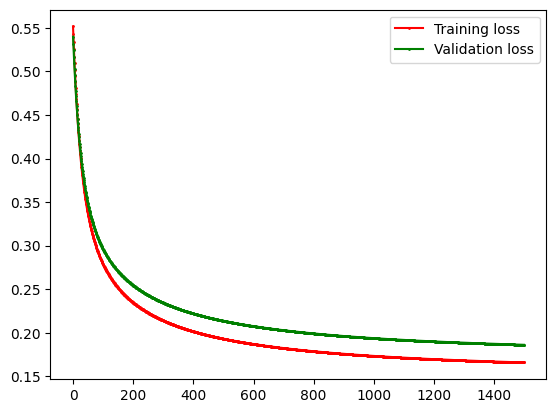

,dim,5
,is_reg,False
,loss_fn,<function log...002831AFA05E0>
,grad_fn,<function log...002831AFA0F40>
,act_fn,<function sig...002837084B740>
,lr,0.1
,reg_type,''
,reg_lambda,0
,n_iteration,50
,val_ratio,0.2
,random_state,None


In [97]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.1,n_iteration =1500,val_ratio=0.2)

In [98]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9231
Precision : 0.9330
Recall    : 0.9278
F1-score  : 0.9304


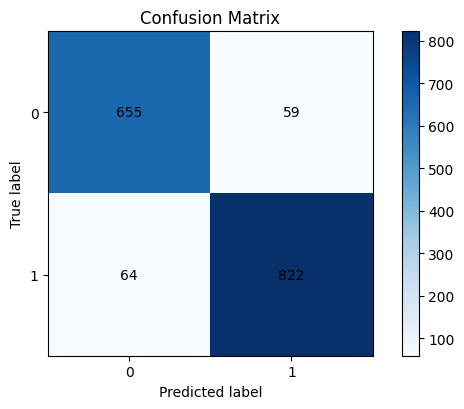

{'Accuracy': 0.923125,
 'Precision': 0.9330306469920545,
 'Recall': 0.927765237020316,
 'F1-score': 0.9303904923599321}

In [99]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

Plot validation set and decision boundary

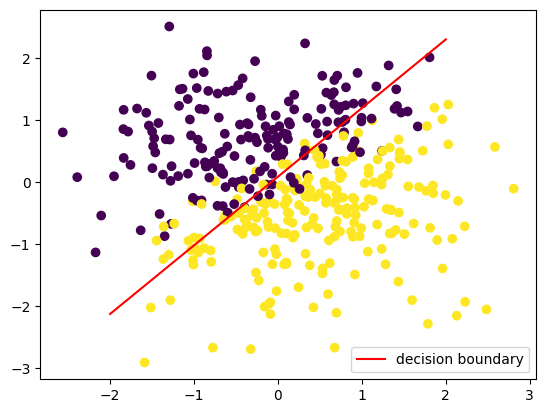

In [9]:
# Plot
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()